In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import netCDF4 as nc
from scipy.stats import linregress
from scipy.spatial import cKDTree


In [2]:
df_ameda = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/AMEDA/df_ameda_renamed.pkl')
df_tilt = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/AMEDA/df_tilt_ameda.pkl')
df_ameda = df_ameda.merge(
    df_tilt[['Eddy', 'Day', 'TiltDis', 'TiltDir']],
    how='left',
    left_on=['Eddy', 'Day'],
    right_on=['Eddy', 'Day']
)
df_ameda



,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,split2,merge,merge2,shapes2,interaction,interaction2,area,deta,TiltDis,TiltDir
0,1,1462,AE,159.538447,-33.372496,256,186,895.838095,919.548973,0.00001,...,NaN,NaN,NaN,NaN,NaN,NaN,46653.514371,-0.000011,NaN,NaN
1,1,1463,AE,159.686966,-33.160751,257,192,903.002279,946.853133,0.000019,...,NaN,NaN,NaN,NaN,NaN,NaN,4313.383226,-0.000164,NaN,NaN
2,1,1464,AE,159.649836,-33.118402,256,192,898.424872,950.150915,0.000019,...,NaN,NaN,NaN,NaN,NaN,NaN,4336.799061,-0.00007,NaN,NaN
3,1,1465,AE,159.686966,-33.118402,257,193,901.765461,951.353349,0.000019,...,NaN,NaN,NaN,NaN,NaN,NaN,6480.379311,-0.000047,16.147158,80.585819
4,1,1466,AE,159.575577,-32.949006,254,196,886.770848,965.738198,0.00002,...,NaN,NaN,NaN,NaN,NaN,NaN,6101.676103,-0.000401,19.455358,63.680275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104565,3519,10643,CE,154.897235,-28.841152,125,252,327.112431,1244.142958,-0.000014,...,NaN,NaN,NaN,NaN,NaN,NaN,1147.953129,0.000186,5.535800,317.157035
104566,3519,10647,CE,154.860106,-29.052897,127,247,331.141370,1220.843200,-0.000011,...,NaN,NaN,NaN,NaN,NaN,NaN,8038.013328,0.000109,13.057427,343.183493
104567,3519,10648,CE,154.897235,-29.222293,130,244,340.502393,1204.416117,-0.000011,...,NaN,NaN,NaN,NaN,NaN,NaN,9866.414298,0.000095,NaN,NaN
104568,3519,10649,CE,154.37742,-28.417662,100,257,264.105244,1270.945276,-0.00001,...,NaN,NaN,NaN,NaN,NaN,NaN,5581.424065,0.000003,NaN,NaN


In [3]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'
dataset = nc.Dataset(fname)
lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))
def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2
dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])
x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')

levels_lat = [-40, -35, -30, -25]
levels_lon = [150, 155, 160]


In [4]:
# Dimensionless Time
df_ameda['norm_time'] = (
    df_ameda.groupby('Eddy')
    .cumcount() / (df_ameda.groupby('Eddy')['Eddy'].transform('size') - 1)
)


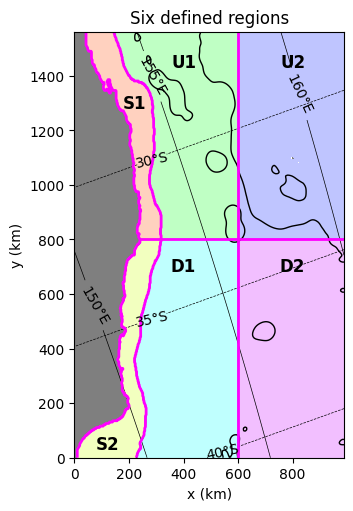

In [5]:
region_mask_grid = (h < 4e3) & (X_grid < 400) & (lon_rho < 154.85) & (mask_rho == 1)

xsplit = 600
ysplit = 800

bin_grid = np.full(X_grid.shape, np.nan)

# left region, split into two by y = 800
bin_grid[region_mask_grid & (Y_grid >= ysplit)] = 1
bin_grid[region_mask_grid & (Y_grid <  ysplit)] = 2

# outside region, left of x = 600, split by boundary of region_mask_grid
bin_grid[(~region_mask_grid) & (X_grid < xsplit) & (mask_rho == 1) & (Y_grid >= ysplit)] = 3
bin_grid[(~region_mask_grid) & (X_grid < xsplit) & (mask_rho == 1) & (Y_grid <  ysplit)] = 4

# right of x = 600, split by y = 800
bin_grid[(X_grid >= xsplit) & (mask_rho == 1) & (Y_grid >= ysplit)] = 5
bin_grid[(X_grid >= xsplit) & (mask_rho == 1) & (Y_grid <  ysplit)] = 6


fig, ax = plt.subplots(1, 1, figsize=(5, 5), constrained_layout=True)

ax.contourf(X_grid, Y_grid, np.where(mask_rho == 0, 1, np.nan),
            levels=[0.5, 1.5], colors=['k'], alpha=.5)

ax.contourf(X_grid, Y_grid, bin_grid,
            levels=np.arange(0.5, 7.5, 1),
            alpha=0.25, cmap='gist_rainbow')

c1 = ax.contour(X_grid, Y_grid, lat_rho, levels=levels_lat, colors='k', linewidths=.5)
ax.clabel(c1, fmt=lambda v: f"{np.abs(v):.0f}°S", inline=True, colors='k')

c2 = ax.contour(X_grid, Y_grid, lon_rho, levels=levels_lon, colors='k', linewidths=.5)
ax.clabel(c2, fmt=lambda v: f"{v:.0f}°E", inline=True, colors='k')

ax.contour(X_grid, Y_grid, h, levels=[4000], colors='k', linewidths=1)
ax.contour(X_grid, Y_grid, region_mask_grid.astype(float),
           levels=[0.5], colors='magenta', linewidths=2)

ax.axvline(xsplit, color='magenta', lw=2)
# ax.axhline(ysplit, color='k', lw=1)
ax.plot([240, X_grid.max()], [ysplit, ysplit], 'magenta', lw=2)

ax.text(220, 1300, 'S1', ha='center', va='center', fontsize=12, fontweight='bold')
ax.text(120, 50, 'S2', ha='center', va='center', fontsize=12, fontweight='bold')
ax.text(400, 1450, 'U1', ha='center', va='center', fontsize=12, fontweight='bold')
ax.text(800, 1450, 'U2', ha='center', va='center', fontsize=12, fontweight='bold')
ax.text(400, 700, 'D1', ha='center', va='center', fontsize=12, fontweight='bold')
ax.text(800, 700, 'D2', ha='center', va='center', fontsize=12, fontweight='bold')

ax.set_aspect('equal')
ax.set_xlim(X_grid.min(), X_grid.max())
ax.set_ylim(Y_grid.min(), Y_grid.max())
ax.set_xlabel('x (km)')
ax.set_ylabel('y (km)')
ax.set_title('Six defined regions')

plt.show()


In [6]:
region_names = {
    1: 'S1',
    2: 'S2',
    3: 'U1',
    4: 'D1',
    5: 'U2',
    6: 'D2'
}

valid = np.isfinite(bin_grid)

tree = cKDTree(np.c_[X_grid[valid], Y_grid[valid]])

dist, idx = tree.query(df_ameda[['xc', 'yc']].to_numpy())

regions_num = bin_grid[valid][idx].astype(int)

df_ameda['region_num'] = regions_num
df_ameda['region'] = df_ameda['region_num'].map(region_names)
df_ameda


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,shapes2,interaction,interaction2,area,deta,TiltDis,TiltDir,norm_time,region_num,region
0,1,1462,AE,159.538447,-33.372496,256,186,895.838095,919.548973,0.00001,...,NaN,NaN,NaN,46653.514371,-0.000011,NaN,NaN,0.000000,5,U2
1,1,1463,AE,159.686966,-33.160751,257,192,903.002279,946.853133,0.000019,...,NaN,NaN,NaN,4313.383226,-0.000164,NaN,NaN,0.014085,5,U2
2,1,1464,AE,159.649836,-33.118402,256,192,898.424872,950.150915,0.000019,...,NaN,NaN,NaN,4336.799061,-0.00007,NaN,NaN,0.028169,5,U2
3,1,1465,AE,159.686966,-33.118402,257,193,901.765461,951.353349,0.000019,...,NaN,NaN,NaN,6480.379311,-0.000047,16.147158,80.585819,0.042254,5,U2
4,1,1466,AE,159.575577,-32.949006,254,196,886.770848,965.738198,0.00002,...,NaN,NaN,NaN,6101.676103,-0.000401,19.455358,63.680275,0.056338,5,U2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104565,3519,10643,CE,154.897235,-28.841152,125,252,327.112431,1244.142958,-0.000014,...,NaN,NaN,NaN,1147.953129,0.000186,5.535800,317.157035,0.555556,3,U1
104566,3519,10647,CE,154.860106,-29.052897,127,247,331.141370,1220.843200,-0.000011,...,NaN,NaN,NaN,8038.013328,0.000109,13.057427,343.183493,0.666667,3,U1
104567,3519,10648,CE,154.897235,-29.222293,130,244,340.502393,1204.416117,-0.000011,...,NaN,NaN,NaN,9866.414298,0.000095,NaN,NaN,0.777778,3,U1
104568,3519,10649,CE,154.37742,-28.417662,100,257,264.105244,1270.945276,-0.00001,...,NaN,NaN,NaN,5581.424065,0.000003,NaN,NaN,0.888889,1,S1


In [7]:
styles = {
    'AE': {'line': 'tab:red',  'fill': 'tab:red'},
    'CE': {'line': 'tab:blue', 'fill': 'tab:blue'}
}

def plot_region_panel(ax, df, xcol='norm_time', ycol='TiltDis', nbins=12, fit_percentiles=(10, 90)):
    
    df = df.dropna(subset=[xcol, ycol, 'Cyc']).copy()
    
    if len(df) < 5:
        return
    
    x_min, x_max = df[xcol].min(), df[xcol].max()
    bins = np.unique(np.quantile(df[xcol], np.linspace(0, 1, nbins + 1)))
    
    if len(bins) < 3:
        bins = np.linspace(x_min, x_max, nbins + 1)
        
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    
    for cyc in ['AE', 'CE']:
        
        dfc = df[df.Cyc == cyc].dropna(subset=[xcol, ycol])
        
        if len(dfc) < 5:
            continue
        
        x = dfc[xcol].values
        y = dfc[ycol].values
        
        d = np.digitize(x, bins)
        
        med = np.array([
            np.nanmedian(y[d == i]) if np.any(d == i) else np.nan
            for i in range(1, len(bins))
        ])
        
        q25 = np.array([
            np.nanquantile(y[d == i], 0.25) if np.any(d == i) else np.nan
            for i in range(1, len(bins))
        ])
        
        q75 = np.array([
            np.nanquantile(y[d == i], 0.75) if np.any(d == i) else np.nan
            for i in range(1, len(bins))
        ])
        
        m = np.isfinite(med)
        
        ax.plot(bin_centers[m], med[m], lw=2.5, color=styles[cyc]['line'])#, label=f'{cyc} median')
        ax.fill_between(bin_centers[m], q25[m], q75[m], color=styles[cyc]['fill'], alpha=0.12)
        
        lo, hi = np.nanpercentile(x, fit_percentiles)
        fit_mask = (x >= lo) & (x <= hi)
        
        if fit_mask.sum() > 2:
            # mreg, c, r, p, se = linregress(x[fit_mask], y[fit_mask])
            mreg, c, r, p, se = linregress(x, y)
            # xf = np.linspace(lo, hi, 100)
            xf = np.linspace(0, 1, 100)
            ax.plot(
                xf, mreg * xf + c,
                '--', lw=2.5, color=styles[cyc]['fill'],
                label=fr'{cyc}: TD={mreg:.2f}t {c:+.2f}'
            )
        ax.set_xlim(0,1)
            

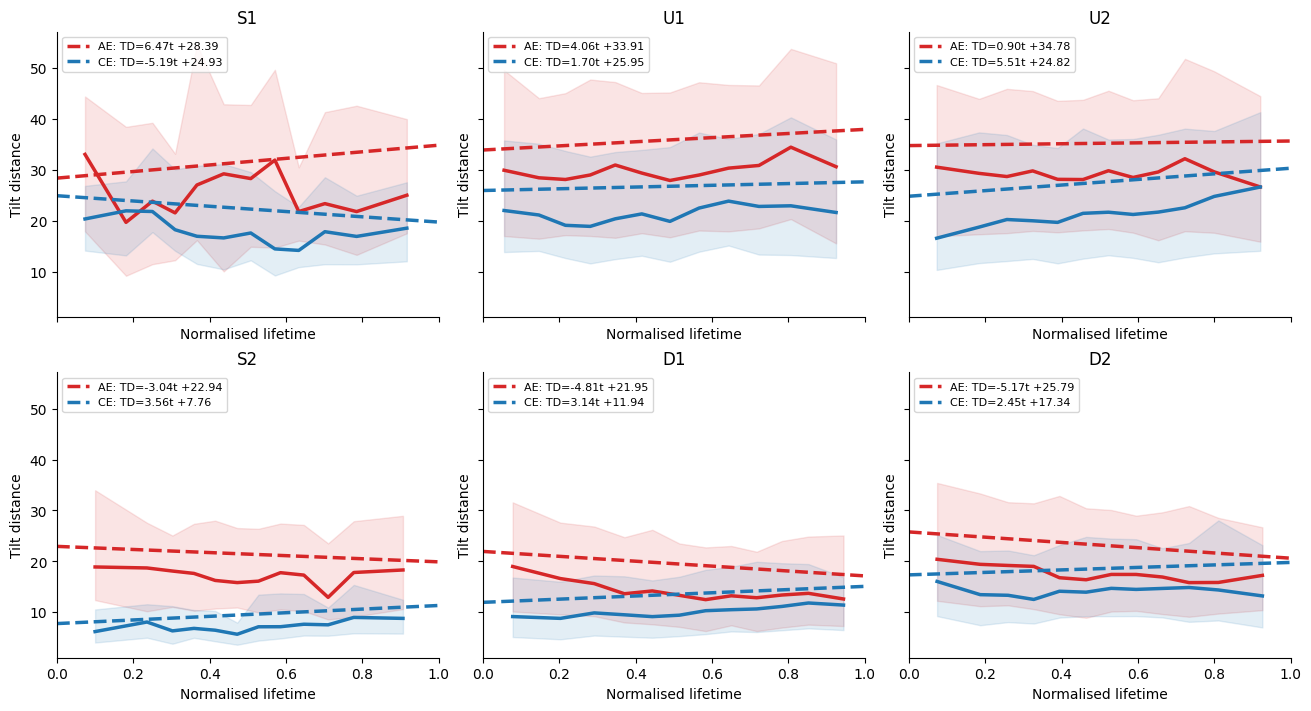

In [8]:
fig, axs = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True, constrained_layout=True)

ax_map = {
    'S1': axs[0, 0],
    'S2': axs[1, 0],
    'U1': axs[0, 1],
    'U2': axs[0, 2],
    'D1': axs[1, 1],
    'D2': axs[1, 2],
}

for region, ax in ax_map.items():
    
    df_region = df_ameda[df_ameda.region == region].copy()
    
    plot_region_panel(ax, df_region, xcol='norm_time', ycol='TiltDis', nbins=12)
    
    ax.set_title(region)
    ax.set_xlabel('Normalised lifetime')
    ax.set_ylabel('Tilt distance')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(fontsize=8, loc='upper left')

plt.show()


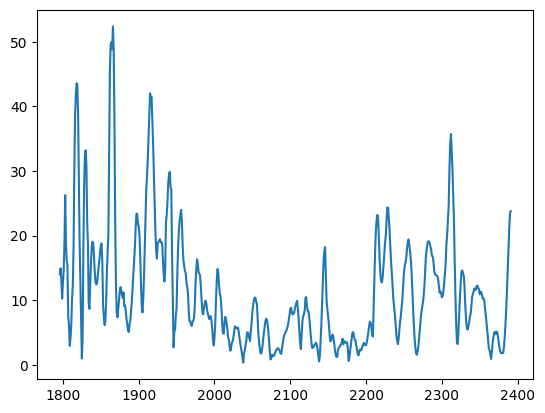

In [9]:
df_old_eddy = df_ameda[df_ameda.Age==df_ameda.Age.max()]
plt.plot(df_old_eddy.Day, df_old_eddy.TiltDis)


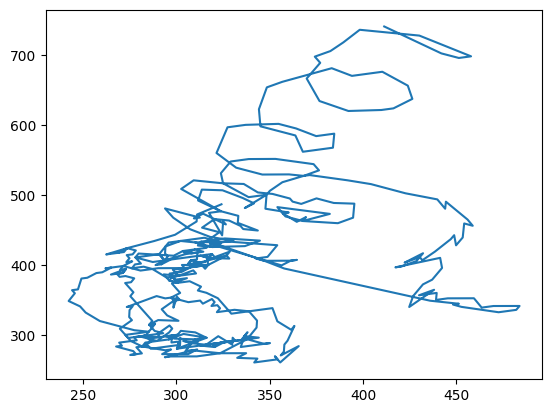

In [10]:
plt.plot(df_old_eddy.xc, df_old_eddy.yc)
